In [2]:
import astropy.units as u
import lsst.daf.butler as dafButler
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from numba.np.arraymath import np_nansum
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score
# from scipy.stats import binned_statistic_2d

#from lsst.pipe.tasks.postprocess import ModelExtendednessColumnAction

mpl.rcParams.update({"image.origin": "lower", "font.size": 15})

In [3]:
# config overrides
fluxerr_coefficent = 0.5 # ModelExtendednessColumnAction.fluxerr_coefficent.default

In [4]:
 # load data
butler = dafButler.Butler(
    "dp2_prep",
    collections=("u/dtaranu/DM-50135/DP2/v30_0_8/matched_cdfs", "u/dtaranu/DM-50135/DP2/v30_0_8/matched_cosmos"),
)
#butler_dp1 = dafButler.Butler(
#    "dp1_prep",
#    collections="u/dtaranu/DM-50135/DP1_expfit/matched_cdfs",
#)

objects = {
    "cdfs": butler.get("matched_cdfs_mast_euclid_q1_object", skymap="lsst_cells_v2", tract=5063),
    #"cdfs_dp1": butler_dp1.get("matched_cdfs_mast_euclid_q1_object", skymap="lsst_cells_v1", tract=5063),
    #"cosmos": butler.get("matched_cosmos_mast_desi_hsc_object", skymap="lsst_cells_v2", tract=9813),
}
#objects["cdfs_dp1"].rename_columns(
#    ("exponential_delta_ll_fit_linear", "exponential_delta_ll_fit_ps"),
#    ("exponential_delta_lnL_fit_linear", "exponential_delta_lnL_fit_ps"),
#)

In [30]:
# convenience functions
#def flux2mag(flux):
#    return (flux*u.nJy).to(u.ABmag).value

def flux2mag(flux):
    zeropoint = 31.4
    index = flux.index if hasattr(flux, 'index') else None
    flux = np.asarray(flux, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        mag = -2.5 * np.log10(flux) + zeropoint
    mag[~np.isfinite(mag)] = np.nan
    if index is not None:
        return pd.Series(mag, index=index)
    return mag

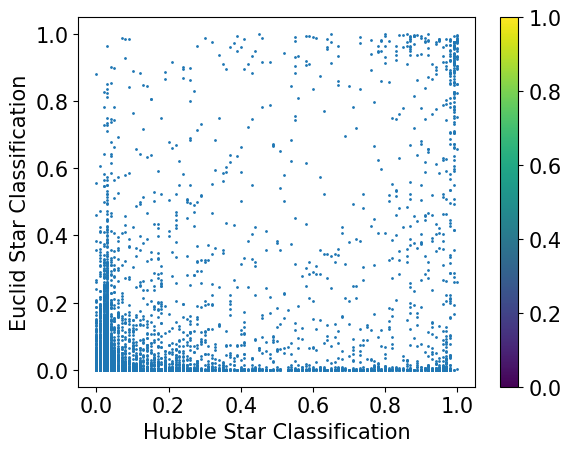

In [6]:
## cleaning up data
cdfs = objects["cdfs"]
# ignoring hst_class_star = -99 bc I assume that's supposed to be a throwaway
cdfs_good = cdfs[(np.isfinite(cdfs['euclid_point_like_prob']) & np.isfinite(cdfs['hst_class_star']))]
# start with hubble quality mask
good_mask = (cdfs_good['hst_class_star']>=0) & (cdfs_good['hst_flags'] == 0)
# then euclid quality mask, being strict on the quality flags at first
good_mask &= (cdfs_good['euclid_spurious_flag']==0) & (cdfs_good['euclid_det_quality_flag'] == 0)
cdfs_good = cdfs_good[good_mask]

plt.scatter(cdfs_good['hst_class_star'], cdfs_good['euclid_point_like_prob'], s=1)#, bins = 50, cmin = 1)
plt.xlabel('Hubble Star Classification')
plt.ylabel('Euclid Star Classification')
plt.colorbar()
plt.show()

In [23]:
# euclid calls it a star but hubble doesn't
confused_topleft = cdfs_good[(cdfs_good['hst_class_star']<=0.5)&(cdfs_good['euclid_point_like_prob']>=0.5)]
# hubble calls it a star but euclid doesn't
confused_bottomright = cdfs_good[(cdfs_good['hst_class_star']>=0.5)&(cdfs_good['euclid_point_like_prob']<=0.5)]
agreed_topright = cdfs_good[(cdfs_good['hst_class_star']>=0.5)&(cdfs_good['euclid_point_like_prob']>=0.5)]
agreed_bottomleft = cdfs_good[(cdfs_good['hst_class_star']<=0.5)&(cdfs_good['euclid_point_like_prob']<=0.5)]
# r-i, g-r not helpful plot

In [38]:
confused_bottomright[['euclid_right_ascension','euclid_declination','euclid_object_id']]

euclid_right_ascension,euclid_declination,euclid_object_id
deg,deg,NA
float64,float64,int64
53.096129859477195,-27.88046400254066,-530961298278804640
53.00989277163229,-27.869845735381954,-530098927278698457
53.01701230228874,-27.869142442755056,-530170123278691424
53.11030715246221,-27.912126345979367,-531103071279121263
53.0632977411176,-27.891678505099563,-530632977278916785
53.06732089331435,-27.886320082394743,-530673208278863200
53.113656768460274,-27.90096176539921,-531136567279009617
53.1791931765333,-27.870596515479946,-531791931278705965


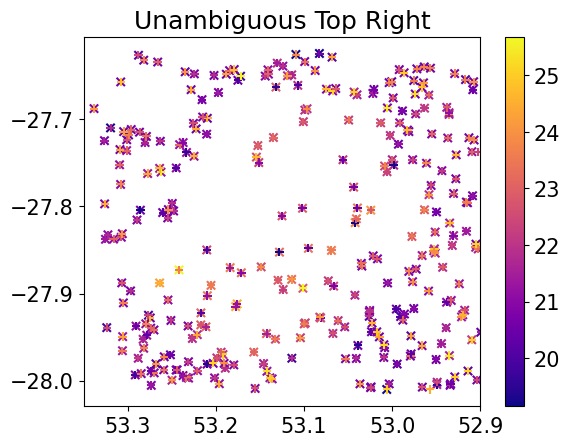

In [32]:
plt.scatter(agreed_topright['hst_ra_gaia'], agreed_topright['hst_dec_gaia'], 
            c = flux2mag(agreed_topright['hst_e_f606w']), cmap = 'plasma',
            marker = 'x', label = 'Hubble')
plt.scatter(agreed_topright['euclid_right_ascension'], agreed_topright['euclid_declination'], 
            c = flux2mag(agreed_topright['euclid_flux_vis_psf']), cmap = 'plasma',
            marker = '+', label = 'Euclid')
plt.colorbar()
plt.title("Unambiguous Top Right")
plt.xlim(53.35,52.9)
plt.show()


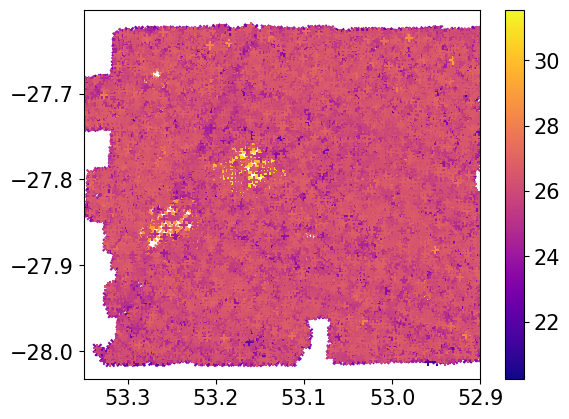

In [33]:
plt.scatter(agreed_bottomleft['hst_ra_gaia'], agreed_bottomleft['hst_dec_gaia'], 
            c = flux2mag(agreed_bottomleft['hst_e_f606w']), cmap = 'plasma',
            marker = 'x', label = 'Hubble')
plt.scatter(agreed_bottomleft['euclid_right_ascension'], agreed_bottomleft['euclid_declination'], 
            c = flux2mag(agreed_bottomleft['euclid_flux_vis_psf']), cmap = 'plasma',
            marker = '+', label = 'Euclid')
plt.colorbar()
plt.xlim(53.35,52.9)
plt.show()

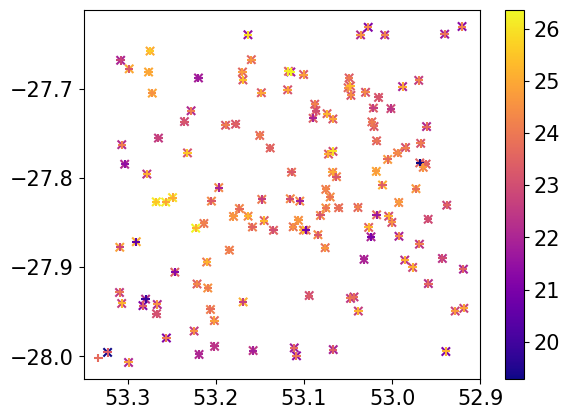

In [14]:
plt.scatter(confused_topleft['hst_ra_gaia'], confused_topleft['hst_dec_gaia'], 
            c = flux2mag(confused_topleft['hst_e_f606w']), cmap = 'plasma',
            marker = 'x', label = 'Hubble')
plt.scatter(confused_topleft['euclid_right_ascension'], confused_topleft['euclid_declination'], 
            c = flux2mag(confused_topleft['euclid_flux_vis_psf']), cmap = 'plasma',
            marker = '+', label = 'Euclid')
plt.colorbar()
plt.xlim(53.35,52.9)
plt.show()

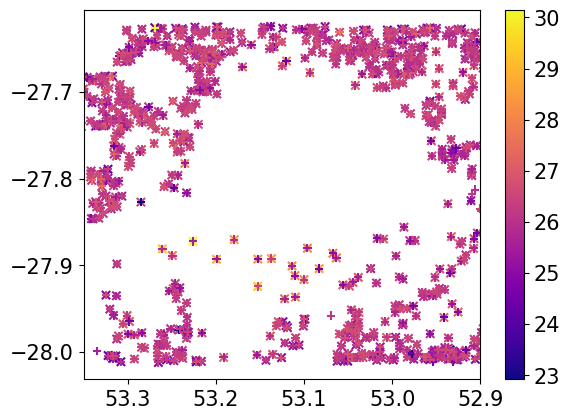

In [15]:
plt.scatter(confused_bottomright['hst_ra_gaia'], confused_bottomright['hst_dec_gaia'], 
            c = flux2mag(confused_bottomright['hst_e_f606w']), cmap = 'plasma',
            marker = 'x', label = 'Hubble')
plt.scatter(confused_bottomright['euclid_right_ascension'], confused_bottomright['euclid_declination'], 
            c = flux2mag(confused_bottomright['euclid_flux_vis_psf']), cmap = 'plasma',
            marker = '+', label = 'Euclid')
plt.colorbar()
plt.xlim(53.35,52.9)
plt.show()

In [9]:
for col in cdfs.columns:
    if 'hst' in col:
        print(col)
    if 'euclid' in col:
        print(col)
# use the hst_e_... for combined image photometry
#print(np.unique(np.array(cdfs['euclid_det_quality_flag'])))

hst_f_f775w
euclid_flux_vis_sersic
hst_ra_gaia
hst_dec_gaia
euclid_right_ascension
euclid_declination
hst_id
hst_class_star
hst_ra
hst_dec
hst_f_f225w
hst_e_f225w
hst_f_f275w
hst_e_f275w
hst_f_f336w
hst_e_f336w
hst_f_f435w
hst_e_f435w
hst_f_f606w
hst_e_f606w
hst_e_f775w
hst_f_f814w
hst_e_f814w
hst_f_f850lp
hst_e_f850lp
hst_f_f098m
hst_e_f098m
hst_f_f105w
hst_e_f105w
hst_f_f125w
hst_e_f125w
hst_f_f140w
hst_e_f140w
hst_f_f160w
hst_e_f160w
hst_z_spec
hst_star_flag
hst_flags
hst_detection_flag
hst_kron_radius
hst_flux_radius
hst_patch
euclid_object_id
euclid_vis_det
euclid_flux_vis_psf
euclid_flux_y_templfit
euclid_flux_j_templfit
euclid_flux_h_templfit
euclid_flux_y_sersic
euclid_flux_j_sersic
euclid_flux_h_sersic
euclid_fluxerr_vis_psf
euclid_fluxerr_y_templfit
euclid_fluxerr_j_templfit
euclid_fluxerr_h_templfit
euclid_fluxerr_vis_sersic
euclid_fluxerr_y_sersic
euclid_fluxerr_j_sersic
euclid_fluxerr_h_sersic
euclid_point_like_prob
euclid_point_like_flag
euclid_mumax_minus_mag
euclid_spur

In [ ]:
fig,ax = plt.subplots(1,1)
ax.hist(flux2mag(confused_topleft['euclid_flux_vis_psf']), bins=60, histtype = 'step', log = True,
        color = 'r', linestyle = '-', label = 'Ambiguous Source E=S,H=G')
ax.hist(flux2mag(confused_bottomright['euclid_flux_vis_psf']), bins=60, histtype = 'step', log = True,
        color = 'r', linestyle = '--', label = 'Ambiguous Source E=G,H=S')
ax.hist(flux2mag(agreed_topright['euclid_flux_vis_psf']), bins=60, histtype = 'step', log = True,
        color = 'b', linestyle = '-', label = 'Unambiguous Star')
ax.hist(flux2mag(agreed_bottomleft['euclid_flux_vis_psf']), bins=60, histtype = 'step', log = True,
        color = 'b', linestyle = '--', label = 'Unambiguous Galaxy')
ax.set(xlabel = 'Euclid VIS', ylabel = 'log(N)')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

In [ ]:
#probablyyyy galaxies
br_zmag = flux2mag(confused_bottomright['z_psfFlux'])
br_Hmag = flux2mag(confused_bottomright['euclid_flux_h_templfit'])
br_gmag = flux2mag(confused_bottomright['g_psfFlux'])

plt.scatter(br_gmag-br_zmag,br_zmag-br_Hmag, s=1)
plt.xlim(-1,5)
plt.xlabel('g-z')
plt.ylim(-1,1.5)
plt.ylabel('z-H')

In [ ]:
#probablyyy stars
tl_zmag = flux2mag(confused_topleft['z_psfFlux'])
tl_Hmag = flux2mag(confused_topleft['euclid_flux_h_templfit'])
tl_gmag = flux2mag(confused_topleft['g_psfFlux'])

plt.scatter(tl_gmag-tl_zmag,tl_zmag-tl_Hmag, s=1)
plt.xlim(-1,5)
plt.xlabel('g-z')
plt.ylim(-1,1.5)
plt.ylabel('z-H')

In [ ]:
tr_zmag = flux2mag(agreed_topright['z_psfFlux'])
tr_Hmag = flux2mag(agreed_topright['euclid_flux_h_templfit'])
tr_gmag = flux2mag(agreed_topright['g_psfFlux'])

plt.scatter(tr_gmag-tr_zmag,tr_zmag-tr_Hmag, s=1)
plt.xlim(-1,5)
plt.xlabel('g-z')
plt.ylim(-1,1.5)
plt.ylabel('z-H')

In [ ]:
# set up tables
dfs = {}
# to define the bands to use for particular fields (some have y some don't)
bands_default = tuple('grizy'), {'griz': 'g,r,i,z'}
bands_field = {
    'cdfs': (tuple('griz'), {'griz': 'g,r,i,z'}),  # no y-band in cdfs lsstcam
}

for field, df in objects.items():
    bands_single, bands_multi = bands_field.get(field, bands_default)
    bands = bands_single + tuple(bands_multi.keys())
    # bands ends up looking like (g,r,i,z,griz)
    action_ser = ModelExtendednessColumnAction(
        bands=bands_single,
        bands_combined=bands_multi,
        output_column="{band}_deslike_class_ser",
        fluxerr_coefficent=fluxerr_coefficent,
    )
    action_exp = ModelExtendednessColumnAction(
        bands=bands_single,
        bands_combined=bands_multi,
        output_column="{band}_deslike_class_exp",
        model_flux_name="exponential",
        fluxerr_coefficent=fluxerr_coefficent,
    )

    class_hst = df['hst_class_star']
    class_other = df['euclid_point_like_prob' if (field != 'cosmos') else 'cosmos2025_type']

    flux_psf_tot, flux_exp_tot, flux_ser_tot, fluxerr_psf_tot, fluxerr_exp_tot, fluxerr_ser_tot = (
        np.zeros(len(df), dtype=float) for _ in range(6)
    )
    log_size_exp = np.log10(np.sqrt(0.5*(df["exponential_reff_x"]**2 + df["exponential_reff_y"]**2)))
    small = log_size_exp < -0.6

    # fig, ax = plt.subplots(figsize=(15, 15))

    for action in (action_exp, action_ser):
        for k, v in action(df).items():
            df[k] = v

    for band in bands:
        if len(band) > 1:
            flux_psf, flux_exp, flux_ser, fluxerr_psf, fluxerr_exp, fluxerr_ser = (
                flux_psf_tot, flux_exp_tot, flux_ser_tot,
                np.sqrt(fluxerr_psf_tot), np.sqrt(fluxerr_exp_tot), np.sqrt(fluxerr_ser_tot)
            )
        else:
            flux_psf, flux_exp, flux_ser, fluxerr_psf, fluxerr_exp, fluxerr_ser = (
                df[f'{band}_{model}Flux{suffix}'] for suffix in ("", "Err") for model in ("psf", "exponential", "sersic")
            )
            good = (fluxerr_psf > 0) & (fluxerr_exp > 0) & (fluxerr_ser > 0) & (
                flux_psf > 0) & (flux_exp > 0) & (flux_ser > 0)
            # Consider dropping u/y?
            for curr, tot in (
                (flux_psf, flux_psf_tot), (flux_exp, flux_exp_tot), (flux_ser, flux_ser_tot),
            ):
                tot[good] += curr[good]
            for curr, tot in (
                (fluxerr_psf, fluxerr_psf_tot), (fluxerr_exp, fluxerr_exp_tot), (fluxerr_ser, fluxerr_ser_tot),
            ):
                tot[good] += curr[good]**2

        df["multi_psfFlux"] = flux_psf
        df["multi_psfFluxErr"] = fluxerr_psf
        df["multi_sersicFlux"] = flux_ser
        df["multi_sersicFluxErr"] = fluxerr_ser

        psf_sn = flux_psf/fluxerr_psf
        good = small & (psf_sn > 10) & (psf_sn < 100)
        for (name, flux_mod, fluxerr_mod) in (
            ("exp", flux_ser, fluxerr_exp), ("ser", flux_ser, fluxerr_ser)
        ):
            flux_ratio = np.array(flux_psf/flux_mod)
            flux_ratio_small = np.nanmedian(flux_ratio[good & (flux_psf/fluxerr_psf > 10)])
            flux_ratio *= 1./flux_ratio_small

        class_magdiff = np.sqrt(8*np.abs(flux_ratio - 1))
        class_magdiff = class_magdiff/(1 + class_magdiff)
        df[f"{band}_extendedness_cont"] = class_magdiff

    dfs[field] = (df, class_hst, class_other)
    print(field, len(df))

In [ ]:
bands_single, bands_multi = bands_field.get('cdfs', bands_default)
bands_single+tuple(bands_multi.keys())

In [ ]:
# plot ROC
for field, (df_full, class_hst, class_other) in dfs.items():
    # just to get a tuple of all individual bands and then combined bands string
    bands_single, bands_multi = bands_field.get(field, bands_default)
    bands = bands_single + tuple(bands_multi.keys())
    # 
    good = (
        (class_hst >= 0) & (class_hst <= 1)
        & (class_other >= 0) & (class_other <= 1)
        & (df_full['refExtendedness'] >= 0) & (df_full['refExtendedness'] <= 1)
    )
    df = df_full[good]
    class_hst_good, class_other_good = class_hst[good], class_other[good]
    n_good = len(df)
    def_gal = (class_hst_good + class_other_good) <= 0.5
    def_star = (2 - class_hst_good - class_other_good) <= 0.5
    print(f'{field} {n_good=} n_star={def_star.sum()} n_gal={def_gal.sum()} n_ambig={np.sum(~(def_star | def_gal))}')

    for subtype, invert in (("star", True), ("galaxy", False)):
        fig, ax = plt.subplots(3, 2, figsize=(15, 15))
        fig_th, ax_th = plt.subplots(3, 2, figsize=(15, 15))

        if not invert:
            fig_roc, ax_roc = plt.subplots(3, 2, figsize=(15, 15))

        def_s = np.array(def_star if invert else def_gal)
        func = (lambda v: 1. - v) if invert else (lambda v: v)

        assert type(ax_th) == type(ax)

        for idx_b, band in enumerate(bands):
            classifiers = [
                {"name":f'deslike (Exp)','predicted':func(df[f'{band}_deslike_class_exp']),
                 'color':'blue'},
                {"name":f'deslike (Ser)','predicted':func(df[f'{band}_deslike_class_ser']),
                 'color':'red', 'lw': 4},
                # {"name":'magdiff','predicted':func(df[f'{band}_extendedness_cont']),'color':'black'},
            ]
            is_multi = band in bands_multi
            if is_multi and ("refSizeExtendedness" in df.colnames):
                classifiers.append({
                    'name': 'refSizeExtendedness', 'predicted': func(df['refSizeExtendedness']), 'color': 'k', 'lw': 3,
                })
                print(f'{band=} in {bands_multi=}')
            idx_classifier_last = len(classifiers) - 1
            idx_ax_1, idx_ax_2 = idx_b//2, idx_b % 2
            axis, axis_th = (a[idx_ax_1][idx_ax_2] for a in (ax, ax_th))
            if not invert:
                axis_roc = ax_roc[idx_ax_1][idx_ax_2]

            for idx_c, classifier in enumerate(classifiers):
                name = classifier['name']
                lsst_predicted = np.array(classifier['predicted'])
                mask = np.all([np.isfinite(a) for a in [lsst_predicted, def_s]], axis=0)
                n_bad = np.sum(mask == 0)
                lsst_predicted_clean = lsst_predicted[mask]
                if n_bad > 0:
                    pass #print(f"{field} {band=} {classifier['name']=} has {n_bad=} from {np.sum(np.isnan(lsst_predicted))=}")

                secure = (lsst_predicted_clean > 0.8)
                true_clean = def_s[mask]
                n_class = np.sum(secure)
                n_class_true = np.sum(true_clean)
                n_tp = np.sum(secure & true_clean)
                n_tn = np.sum(~secure + ~true_clean)
                n_fp = np.sum(secure & ~true_clean)
                purity = 100.*n_tp/n_class
                compl = 100.*n_tp/n_class_true
                fpr = 100.*n_fp/(n_fp + n_tn)
                pc_refext = None
                if idx_c == 0:
                    print(f"{subtype} {invert} {name} {band} {n_class_true=} {n_class=} {n_tp=}"
                          f" {purity=:.1f} {compl=:.1f} {fpr=:.1f}")
                elif is_multi and (idx_c == idx_classifier_last):
                    predicted_refext = func(df["refExtendedness"])
                    print(np.sum(predicted_refext.mask))
                    predicted_refext.value[predicted_refext.mask == True] = np.nan
                    predicted_refext = predicted_refext.value
                    mask = np.all([np.isfinite(a) for a in [predicted_refext, def_s]], axis=0)
                    print(np.sum(~np.isfinite(predicted_refext)), np.sum(mask))
                    secure = predicted_refext[mask] > 0.5
                    true_clean_ext = def_s[mask]
                    n_class = np.sum(secure)
                    n_class_true = np.sum(true_clean_ext)
                    n_tp = np.sum(secure & true_clean_ext)
                    n_tn = np.sum(~secure + ~true_clean_ext)
                    n_fp = np.sum(secure & ~true_clean_ext)
                    purity_refext = 100.*n_tp/n_class
                    compl_refext = 100.*n_tp/n_class_true

                    print(f"{subtype} {invert} {name} {band} {n_class_true=} {n_class=} {n_tp=}"
                          f" {purity_refext=:.1f} {compl_refext=:.1f} {fpr=:.1f}")
                    pc_refext = purity_refext/100., compl_refext/100.

                arr_isinf = np.isinf(lsst_predicted_clean)
                precision, recall, thresholds = precision_recall_curve(true_clean, lsst_predicted_clean)
                auc_pr = average_precision_score(true_clean, lsst_predicted_clean)
                good = (thresholds > 0) & (thresholds < 1)
                x_thresh = func(thresholds[good][::-1])
                precision_y = precision[1:][good][::-1]
                recall_y = recall[1:][good][::-1]
                if idx_c == 2:
                    print(precision_y, recall_y)
                
                axes_plots = [
                    (axis_th, x_thresh, precision_y, '-', ' Purity'),
                    (axis_th, x_thresh, recall_y, '--', ' Completeness'),
                    (axis, recall_y, precision_y, '-', f'(AUC={auc_pr:.2f}')
                ]
                if not invert:
                    fpr, tpr, thresholds = roc_curve(true_clean, lsst_predicted_clean)
                    auc_roc = auc(fpr, tpr)
                    good = (thresholds > 0) & (thresholds < 1)
                    x_thresh = func(thresholds[good][::-1])
                    fpr_y = fpr[good][::-1]
                    tpr_y = tpr[good][::-1]

                    axes_plots.append(
                        (axis_roc, fpr, tpr, '-', f'(AUC={auc_roc:.2f}')
                    )
                
                for axis_plot, x, y, linestyle, suffix in axes_plots:
                    axis_plot.plot(
                        x, y,
                        color=classifier['color'], ls=linestyle,
                        lw=classifier.get('lw', 2),
                        label=f"{name}{suffix}",
                    )
                if pc_refext is not None:
                    axis.scatter(pc_refext[1], pc_refext[0], s=100, c='gray', label="refExtendedness")
            for axis_ in [axis] + ([] if invert else [axis_roc]):
                axis.set_xlim([0.0, 1.0])
                axis.set_ylim([0.0, 1.05])
                axis.axhline(1.0, 0.0, 1.0, lw=1)
            axis.set_xlabel(f'{band}-band Completeness')
            axis.set_ylabel('Purity')
            axis.legend(loc="lower left")
            axis_th.set_xlabel('Threshold')
            axis_th.set_ylabel(f'{band}-band Completeness/Purity')
            if not invert:
                axis_roc.set_xlabel(f'{band}-band False Positive Rate')
                axis_roc.set_ylabel('True Positive Rate')

        ax_th[0][0].legend(loc='center right')

        fig.suptitle(f'{field} Precision-Recall Curve (True {subtype})')
        fig_th.suptitle(f'{field} Completeness/Purity vs Threshold (True {subtype})')
        if not invert:
            fig_roc.suptitle(f'{field} Receiver Operating Characteristic (ROC) Curve (True {subtype})')
        for fig_ in [fig, fig_th] + ([] if invert else [fig_roc]):
            fig_.tight_layout()
    plt.show()

In [ ]:
# Try to eyeball heuristic improvements
cmap = mpl.colormaps["RdYlBu_r"]

for field, (df_full, class_hst, class_other) in dfs.items():
    bands_single, bands_multi = bands_field.get(field, bands_default)
    bands = bands_single + ("multi",)
    good = (
        (class_hst >= 0) & (class_hst <= 1)
        & (class_other >= 0) & (class_other <= 1)
        & (df_full['refExtendedness'] >= 0) & (df_full['refExtendedness'] <= 1)
    )
    df = df_full[good]
    class_hst_good, class_other_good = class_hst[good], class_other[good]
    class_good = class_hst_good + class_other_good
    # Trim most of the most obvious galaxies - there are too many to plot
    def_gal = (class_good > 0.1) & (class_good <= 0.5)
    def_star = (2 - class_good) <= 0.5
    def_ambig = (~(class_good <= 0.5) & ~def_star)
    print(f"{field} {bands_multi=} {np.sum(def_star)=} {np.sum(def_ambig)=} {np.sum(def_gal)=}")

    n_bands = len(bands)
    fig, ax = plt.subplots(n_bands, 3, figsize=(20, 20))
    log_size_exp = np.clip(
        np.log10(np.sqrt(0.5*(df["exponential_reff_x"]**2 + df["exponential_reff_y"]**2))),
        -2, 2,
    )

    for idx_b, band in enumerate(bands):
        mag_psf = flux2mag(df[f'{band}_psfFlux'])
        ext = df[f'{band if band != 'multi' else next(iter(bands_multi.keys()))}_deslike_class_exp']
        for idx_type, (name, typ) in enumerate((
            ("star", def_star), ("ambiguous", def_ambig), ("galaxy (0.05 < ref_ext < 0.25)", def_gal)
        )):
            axis = ax[idx_b][idx_type]
            if idx_b == 0:
                axis.set_title(name)
            axis.scatter(mag_psf[typ], log_size_exp[typ], s=10, facecolor=cmap(ext[typ]), edgecolor='k', lw=0.5)
            axis.set_xlim(18, 28)
            axis.set_ylim(-2.05, 1.0)
            if idx_type == 0:
                axis.set_ylabel(f"log10(r_eff/pix) ({band}_ext)")

    fig.tight_layout()
    plt.show()

In [ ]:
#
df_full, class_hst, class_other = dfs["cdfs"]
good = (
    (class_hst >= 0) & (class_hst <= 1)
    & (class_other >= 0) & (class_other <= 1)
    & (df_full['refExtendedness'] >= 0) & (df_full['refExtendedness'] <= 1)
)
df = df_full[good]
class_hst_good, class_other_good = class_hst[good], class_other[good]
size_exp = np.sqrt(0.5*(df["exponential_reff_x"]**2 + df["exponential_reff_y"]**2))
log_size_exp = np.clip(np.log10(size_exp), -2, 2)

model = "exponential"

for band in "r":
    flux_psf = df[f"{band}_psfFlux"]
    fluxerr_psf = df[f"{band}_psfFluxErr"]

    flux_model = df[f"{band}_{model}Flux"]
    fluxerr_model = df[f"{band}_{model}FluxErr"]

    mag_psf = flux2mag(flux_psf)

    psf_sn = flux_psf/fluxerr_psf
    ext_ref = (2 - class_hst_good - class_other_good)/2.

    good = (log_size_exp < -0.7) & (psf_sn > 10)

    if band == "i":
        fig, ax = plt.subplots(figsize=(15, 15))
        ax.scatter(mag_psf[~good], log_size_exp[~good], s=5)
        ax.scatter(mag_psf[good], log_size_exp[good], s=5)
        ax.set_xlim(18, 26)
        ax.set_ylim(-1, 1)
        ax.set_xlabel(f"{band} PSF mag")
        ax.set_ylabel("log(r_eff/pix)")

    flux_ratio = np.array(flux_psf/flux_model)
    # Attempt to correct any flux-independent systematic offset
    # Might need to be a function of S/N
    if np.sum(good == True) > 10:
        ratio = 1./np.nanmedian(flux_ratio[good])
        print(f"{band} {ratio=}")
        flux_ratio *= ratio
    flux_ratio_err = np.sqrt(
        (fluxerr_psf/flux_model)**2 + (fluxerr_model*fluxerr_psf/flux_model**2)**2
    )

    small = log_size_exp < 0.3
    label_small = "(log10(r_eff/pix) < 0.3)"

    ref_star = ext_ref <= 0.4
    order_pses = ((~ref_star & ~good, 10), (ref_star & ~good, 40), (ref_star & good, 10), (~ref_star & good, 40))

    fig, ax = plt.subplots(figsize=(15, 15))
    for order, ps in ((~ref_star, 10), (ref_star, 30)):
        sel = order & small
        ax.scatter(mag_psf[sel], np.log10(flux_ratio[sel]), s=ps, facecolor=cmap(ext_ref[sel]), edgecolor='k', lw=0.5)
    ax.set_xlim(18, 26)
    ax.set_ylim(-0.3, 0.1)
    ax.set_xlabel(f"{band} mag {label_small}")
    ax.set_ylabel(f"log10(psfFlux/{model}Flux)")

    extendedness = (1 - flux_ratio) + 2.5*flux_ratio_err
    extendedness[(extendedness < 0) & (extendedness > -np.inf)] = 0

    fig, ax = plt.subplots(figsize=(15, 15))
    ax.scatter(
        extendedness, np.clip(log_size_exp, -1, 1),
        s=2*np.clip(30 - mag_psf, 2, 20), facecolor=cmap(ext_ref), lw=0.5, edgecolor='k',
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(-1, 1)
    ax.set_xlabel(f"{band} ext_deslike")
    ax.set_ylabel("log(r_eff/pix)")


    fig, ax = plt.subplots(figsize=(15, 15))
    for order, ps in order_pses:
        sel = small & order
        ax.scatter(mag_psf[sel], extendedness[sel], s=ps, facecolor=cmap(ext_ref[sel]), edgecolor='k', lw=0.5)
    ax.set_xlim(18, 26)
    ax.set_ylim(0, 0.6)
    ax.set_xlabel(f"{band} mag {label_small}")
    ax.set_ylabel("DES ext (1 - ratio) + 2.5*ratio_err")

    stretch = action_exp.fluxerr_stretch
    extendedness *= np.sqrt(size_exp/action_exp.max_reff_compact)
    extendedness[(extendedness < 0) & (extendedness > -np.inf)] = 0
    # Make it sigmoid-like with a stretch
    extendedness *= stretch
    extendedness = np.clip((stretch + 1)/stretch*extendedness/(1 + extendedness), 0, 1)

    # This is just for plotting
    # extendedness[good] = -ext_ref[good]/10
    extendedness = df[f"{band}_deslike_class_exp"]
    print(np.max(extendedness), len(extendedness), np.sum(~np.isfinite(extendedness)))

    fig, ax = plt.subplots(figsize=(15, 15))
    for order, ps in order_pses:
        sel = order # & small
        ax.scatter(mag_psf[sel], extendedness[sel], s=ps, facecolor=cmap(ext_ref[sel]), edgecolor='k', lw=0.5)
    ax.set_xlim(18, 26)
    ax.set_ylim(-0.01, 1.01)
    ax.set_xlabel(f"{band} mag {label_small}")
    ax.set_ylabel("new extendedness")


In [ ]:
    #
    extendedness = df[f"{band}_deslike_class_exp"]
    print(np.max(extendedness), len(extendedness), np.sum(~np.isfinite(extendedness)), np.sum(extendedness < 0.2))

# stuff below doesn't work yet